In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

In [174]:
date_fns = pd.read_csv("../logs/method-reconstruction-experiment/date-fns/structured/result.csv", escapechar="\\")
directus  = pd.read_csv("../logs/method-reconstruction-experiment/directus/structured/result.csv", escapechar="\\")

df = pd.concat([date_fns, directus], ignore_index=True)

for col in ["isTestSuiteSuccessful", "isModelResultCompilable"]:
    df[col] = df[col].map({"true": True, "false": False, True: True, False: False})

df["passRate"] = df["testSuitePassedTestCaseCount"] / df["testSuiteTotalTestCaseCount"]

print(df.shape)
df.head(3)

(123, 19)


,repositoryName,methodName,methodResolvedFilePath,experimentTitle,experimentContextSlugs,modelSystemPrompt,modelUserPrompt,modelReasoningTextResult,modelName,modelReasoningBudget,modelTemperature,modelResult,isTestSuiteSuccessful,isModelResultCompilable,relevantTestCaseCount,testSuiteTotalTestCaseCount,testSuitePassedTestCaseCount,testSuiteFailedTestCaseCount,passRate
0,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,areIntervalsOverlapping > gemini-2.5-flash|tem...,relevant-test-case,# SYSTEM PROMPT: METHOD RECONSTRUCTORnn## 1. I...,# Method NamennareIntervalsOverlappingnn# Meth...,NaN,gemini-2.5-flash,0,0,const inclusive = options?.inclusive ?? fals...,True,True,5,19,19,0,1.000000
1,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,areIntervalsOverlapping > gemini-2.5-flash|tem...,relevant-test-case,# SYSTEM PROMPT: METHOD RECONSTRUCTORnn## 1. I...,# Method NamennareIntervalsOverlappingnn# Meth...,NaN,gemini-2.5-flash,0,0,const leftStartTime = toDate(intervalLeft.st...,True,True,5,19,19,0,1.000000
2,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,areIntervalsOverlapping > gemini-2.5-flash|tem...,relevant-test-case,# SYSTEM PROMPT: METHOD RECONSTRUCTORnn## 1. I...,# Method NamennareIntervalsOverlappingnn# Meth...,NaN,gemini-2.5-flash,0,0,const intervalLeftStartTime = toDate(interva...,False,True,4,19,18,1,0.947368


In [175]:
# Inspecionar valores únicos dos slugs para entender o encoding
print(df["experimentContextSlugs"].value_counts().head(30))

experimentContextSlugs
relevant-test-case    107
Name: count, dtype: int64


In [176]:
import re

def parse_experiment_title(title: str) -> dict:
    """
    Parseia o experimentTitle no formato:
      "{methodName} > {model}|temperature-{t}|{contextType} [{permIdx}/{totalPerms}]"
    """
    model_match      = re.search(r"(gemini-[\w.-]+)\|", str(title))
    context_match    = re.search(r"gemini-[\w.-]+\|temperature-\d+\|([\w-]+)", str(title))
    perm_match       = re.search(r"\[(\d+)/(\d+)\]", str(title))

    return {
        "model":        model_match.group(1)    if model_match    else None,
        "contextType":  context_match.group(1)  if context_match  else None,
        "permIdx":      int(perm_match.group(1)) if perm_match    else None,
        "totalPerms":   int(perm_match.group(2)) if perm_match    else None,
    }

parsed = df["experimentTitle"].apply(parse_experiment_title).apply(pd.Series)
df = pd.concat([df, parsed], axis=1)

# subsetSize: usa relevantTestCaseCount (varia por método; subconjuntos parciais virão nas permutações)
df["subsetSize"]    = df["relevantTestCaseCount"]
df["isFullContext"] = df["contextType"] != "no-relevant-test-case"

print(df[["experimentTitle", "model", "contextType", "permIdx", "subsetSize"]].drop_duplicates(subset=["contextType","model"]).to_string(index=False))

                                                                           experimentTitle            model                 contextType  permIdx  subsetSize
     areIntervalsOverlapping > gemini-2.5-flash|temperature-0|all-relevant-test-case [1/1] gemini-2.5-flash      all-relevant-test-case        1           5
areIntervalsOverlapping > gemini-2.5-flash|temperature-0|permuted-relevant-test-case [1/5] gemini-2.5-flash permuted-relevant-test-case        1           5
      areIntervalsOverlapping > gemini-2.5-flash|temperature-0|no-relevant-test-case [1/1] gemini-2.5-flash       no-relevant-test-case        1           0
     areIntervalsOverlapping > gemini-3.0-flash|temperature-0|all-relevant-test-case [1/1] gemini-3.0-flash      all-relevant-test-case        1           5
areIntervalsOverlapping > gemini-3.0-flash|temperature-0|permuted-relevant-test-case [1/5] gemini-3.0-flash permuted-relevant-test-case        1           5
      areIntervalsOverlapping > gemini-3.0-flash|temperatu

In [177]:
print("Repositórios:", df["repositoryName"].value_counts().to_dict())
print("Métodos únicos:", df["methodName"].nunique())
print("Modelos:", df["model"].unique())
print("Tipos de contexto:", df["contextType"].unique())
print("Linhas por (modelo, contextType):")
print(df.groupby(["model", "contextType"]).size().to_string())
print("\nTaxa global de sucesso:", round(df["isTestSuiteSuccessful"].mean(), 4))
print("Taxa global de compilabilidade:", round(df["isModelResultCompilable"].mean(), 4))

Repositórios: {'date-fns': 76, 'directus': 47}
Métodos únicos: 9
Modelos: ['gemini-2.5-flash' 'gemini-3.0-flash']
Tipos de contexto: ['all-relevant-test-case' 'permuted-relevant-test-case'
 'no-relevant-test-case']
Linhas por (modelo, contextType):
model             contextType                
gemini-2.5-flash  all-relevant-test-case          9
                  no-relevant-test-case           8
                  permuted-relevant-test-case    45
gemini-3.0-flash  all-relevant-test-case          8
                  no-relevant-test-case           8
                  permuted-relevant-test-case    45

Taxa global de sucesso: 0.1463
Taxa global de compilabilidade: 1.0


## Análise 1 — Taxa de sucesso por tipo de contexto e modelo

**Pergunta:** fornecer testes relevantes melhora o sucesso? Qual modelo performa melhor?

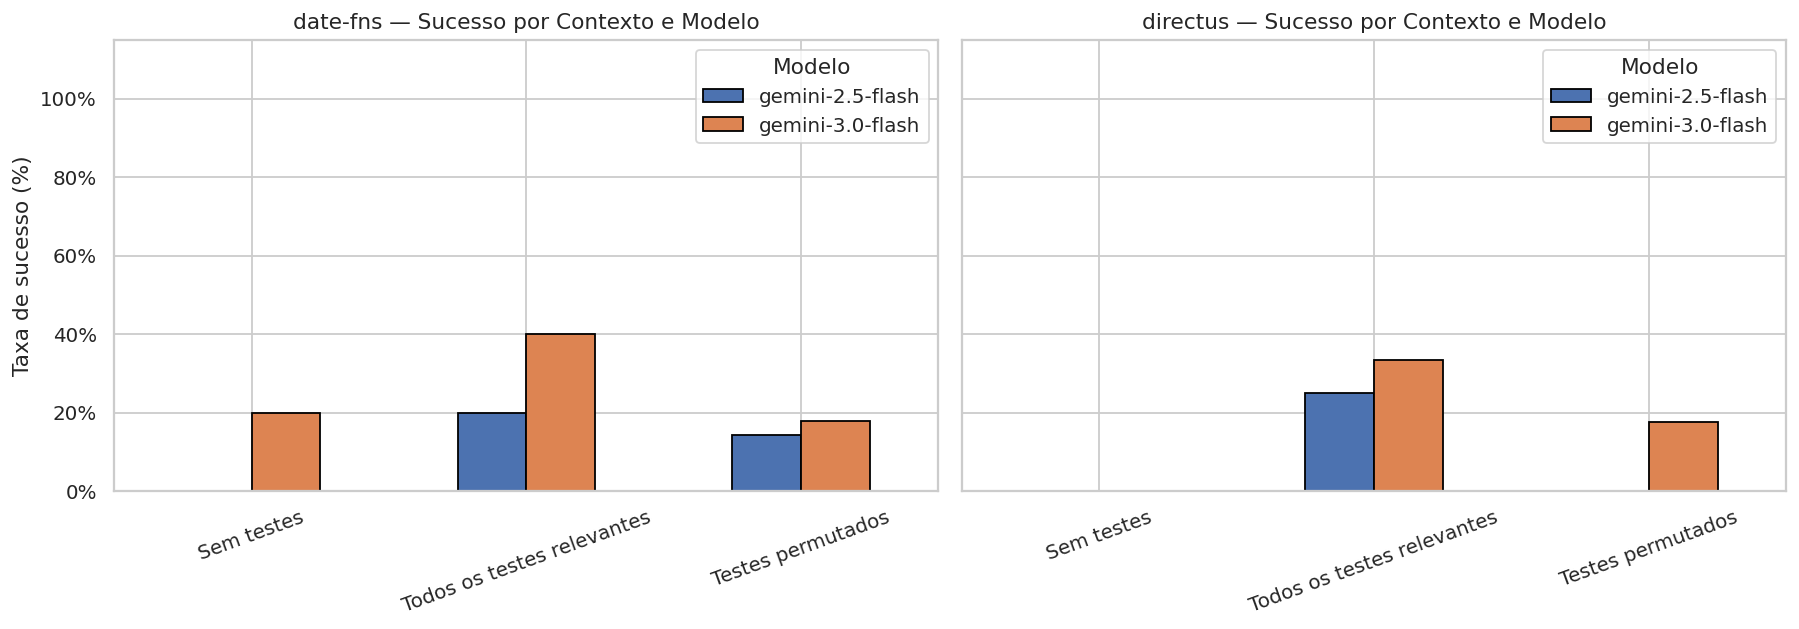

In [178]:
CONTEXT_ORDER = ["no-relevant-test-case", "all-relevant-test-case", "permuted-relevant-test-case"]
CONTEXT_LABELS = {
    "no-relevant-test-case":       "Sem testes",
    "all-relevant-test-case":      "Todos os testes relevantes",
    "permuted-relevant-test-case": "Testes permutados",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, repo in zip(axes, ["date-fns", "directus"]):
    subset = df[df["repositoryName"] == repo]
    rates = (
        subset.groupby(["contextType", "model"])["isTestSuiteSuccessful"]
        .mean()
        .unstack("model")
        .reindex([c for c in CONTEXT_ORDER if c in subset["contextType"].unique()])
    )
    rates.index = [CONTEXT_LABELS.get(i, i) for i in rates.index]
    rates = rates * 100
    rates.plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title(f"{repo} — Sucesso por Contexto e Modelo")
    ax.set_ylabel("Taxa de sucesso (%)")
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("success_by_context_model.png", bbox_inches="tight")
plt.show()

## Análise 2 — Sucesso por método, contexto e modelo (heatmap)

**Pergunta:** quais métodos o LLM reconstrói bem ou mal? O resultado varia por modelo?

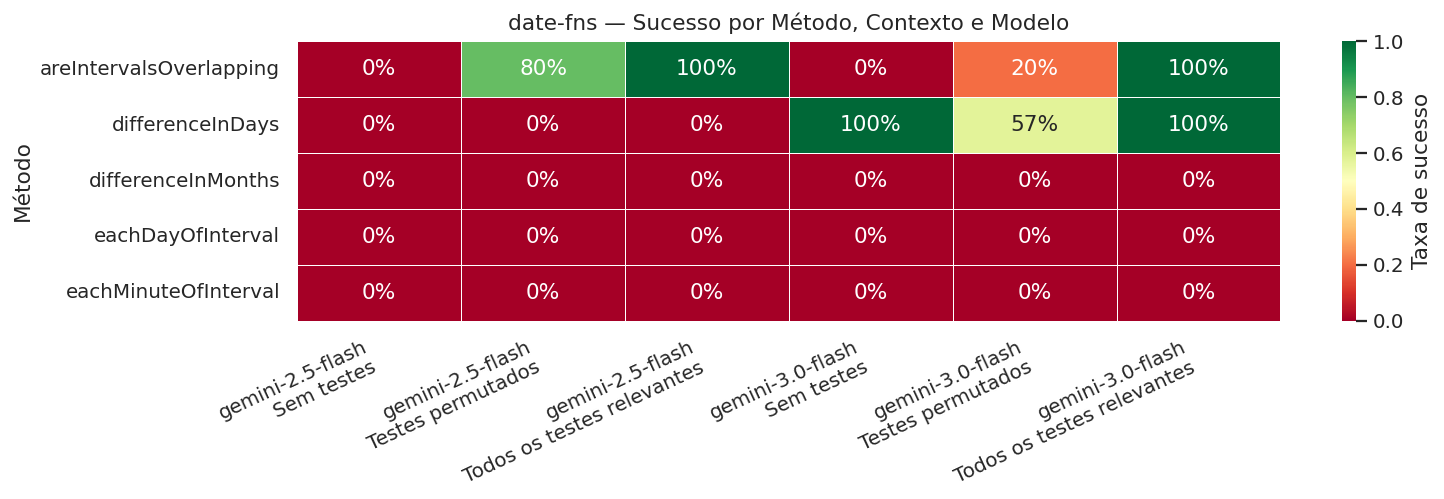

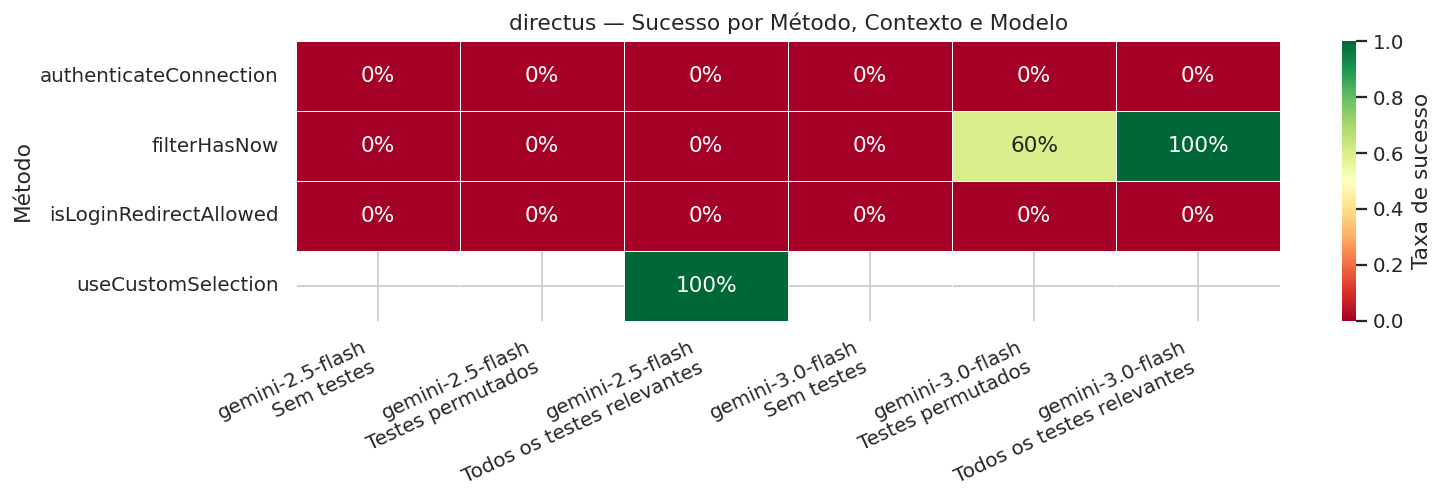

In [179]:
for repo in ["date-fns", "directus"]:
    pivot = (
        df[df["repositoryName"] == repo]
        .groupby(["methodName", "contextType", "model"])["isTestSuiteSuccessful"]
        .mean()
        .reset_index()
        .assign(col=lambda d: d["model"] + "\n" + d["contextType"].map(CONTEXT_LABELS).fillna(d["contextType"]))
        .pivot(index="methodName", columns="col", values="isTestSuiteSuccessful")
        .fillna(np.nan)
    )
    plt.figure(figsize=(max(8, len(pivot.columns) * 2), max(4, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": "Taxa de sucesso"})
    plt.title(f"{repo} — Sucesso por Método, Contexto e Modelo")
    plt.xlabel("")
    plt.ylabel("Método")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(f"heatmap_method_{repo}.png", bbox_inches="tight")
    plt.show()

## Análise 3 — Variância entre permutações (mesmos testes, ordem diferente)

**Pergunta:** a ordem dos testes no prompt afeta o resultado? (`contextType == "permuted-relevant-test-case"`)

In [180]:
permuted_only = df[df["contextType"] == "permuted-relevant-test-case"].copy()

if permuted_only.empty:
    print("Nenhuma execução com 'permuted-relevant-test-case' encontrada nos dados ainda.")
    print("Esta análise ficará disponível quando esses experimentos forem executados.")
else:
    variance = (
        permuted_only.groupby(["repositoryName", "methodName", "model"])["passRate"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"std": "permutationStd"})
        .sort_values("permutationStd", ascending=False)
    )
    print("Métodos mais sensíveis à ordem dos testes:")
    print(variance.to_string(index=False))

Métodos mais sensíveis à ordem dos testes:
repositoryName              methodName            model      mean  permutationStd  count
      date-fns      differenceInMonths gemini-2.5-flash -1.380952        1.166424      6
      date-fns       eachDayOfInterval gemini-3.0-flash  0.466667        0.877664      5
      date-fns        differenceInDays gemini-3.0-flash  0.866667        0.227710      7
      directus  isLoginRedirectAllowed gemini-3.0-flash  0.673469        0.179081      7
      directus            filterHasNow gemini-2.5-flash  0.727273        0.170075      5
      directus  isLoginRedirectAllowed gemini-2.5-flash  0.530612        0.158957      7
      date-fns    eachMinuteOfInterval gemini-3.0-flash  0.780000        0.109545      5
      directus  authenticateConnection gemini-3.0-flash  0.375000        0.088388      5
      date-fns      differenceInMonths gemini-3.0-flash  0.849206        0.070093      6
      directus  authenticateConnection gemini-2.5-flash  0.350000  

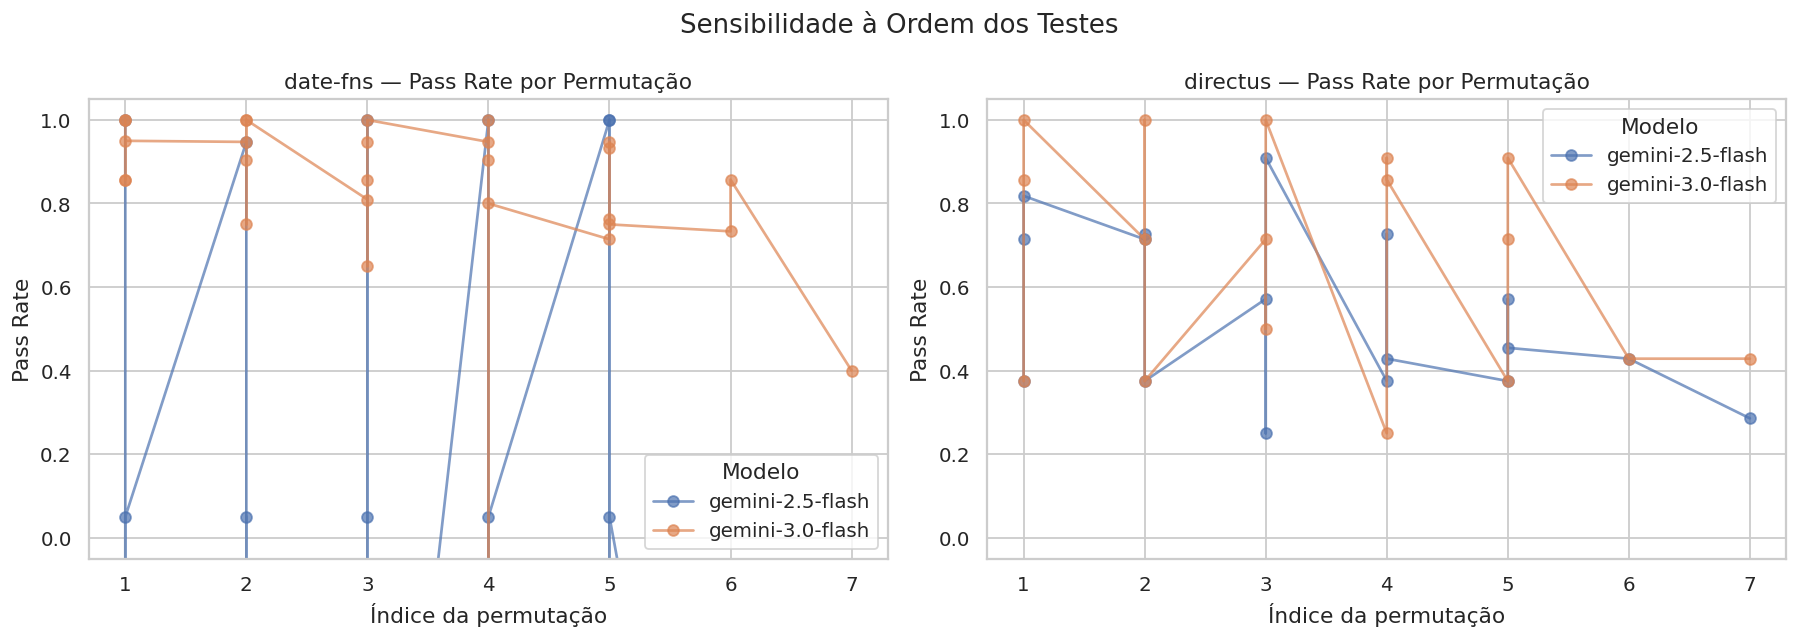

In [181]:
if permuted_only.empty:
    print("Sem dados de permutação para plotar.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, repo in zip(axes, ["date-fns", "directus"]):
        data = permuted_only[permuted_only["repositoryName"] == repo]
        if data.empty:
            ax.text(0.5, 0.5, "Sem dados", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(repo)
            continue
        for model, grp in data.groupby("model"):
            grp_sorted = grp.sort_values("permIdx")
            ax.plot(grp_sorted["permIdx"], grp_sorted["passRate"], marker="o", label=model, alpha=0.7)
        ax.set_title(f"{repo} — Pass Rate por Permutação")
        ax.set_xlabel("Índice da permutação")
        ax.set_ylabel("Pass Rate")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(title="Modelo")

    plt.suptitle("Sensibilidade à Ordem dos Testes")
    plt.tight_layout()
    plt.savefig("permutation_sensitivity.png", bbox_inches="tight")
    plt.show()

## Análise 4 — Correlação: nº de testes relevantes × taxa de sucesso (cross-método)

**Pergunta:** métodos com mais testes relevantes disponíveis tendem a ser reconstruídos com mais sucesso?

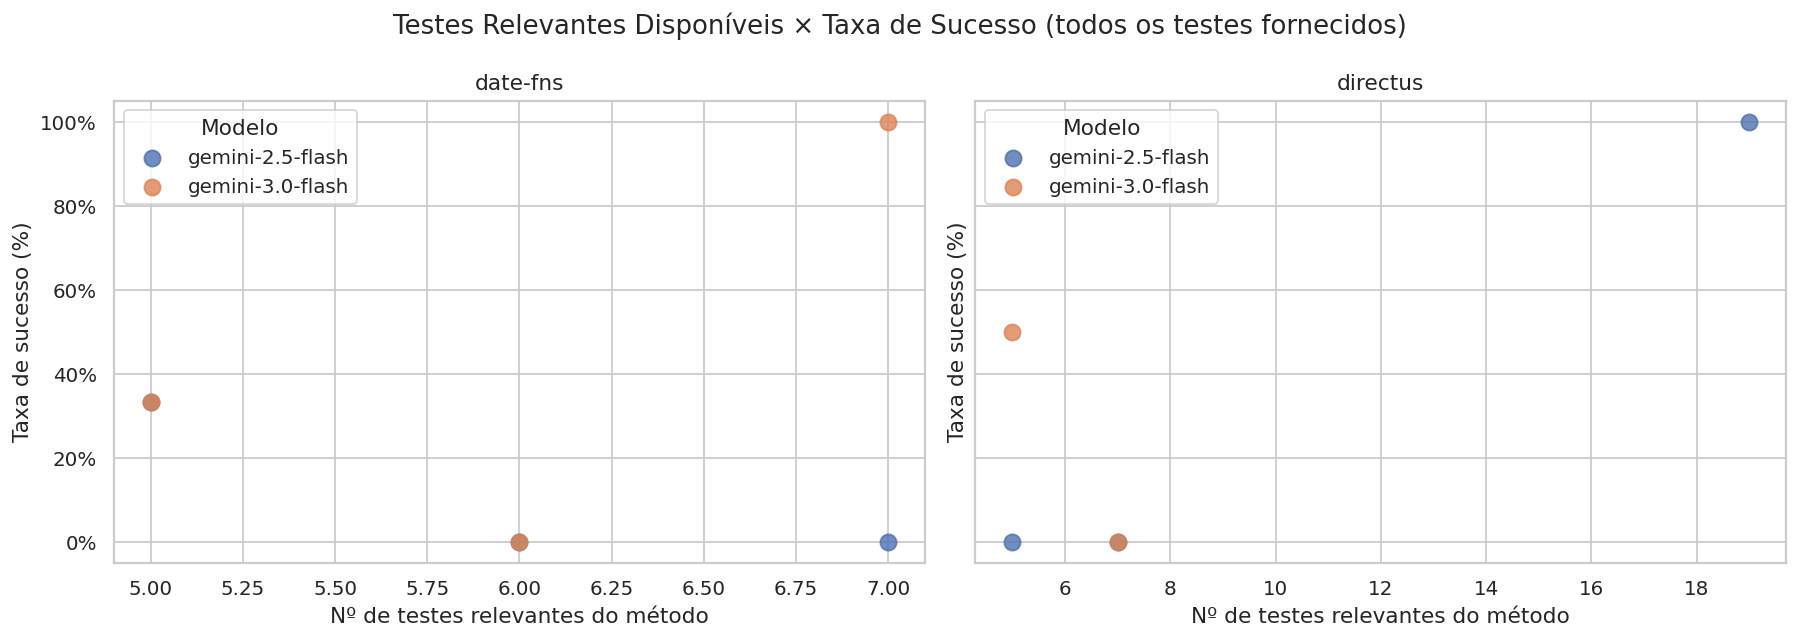

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, repo in zip(axes, ["date-fns", "directus"]):
    subset = df[(df["repositoryName"] == repo) & (df["contextType"] == "all-relevant-test-case")]
    for model, grp in subset.groupby("model"):
        agg = grp.groupby("subsetSize")["isTestSuiteSuccessful"].mean() * 100
        ax.scatter(agg.index, agg.values, label=model, s=80, alpha=0.8)
    ax.set_title(f"{repo}")
    ax.set_xlabel("Nº de testes relevantes do método")
    ax.set_ylabel("Taxa de sucesso (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Modelo")

plt.suptitle("Testes Relevantes Disponíveis × Taxa de Sucesso (todos os testes fornecidos)")
plt.tight_layout()
plt.savefig("relevant_count_vs_success.png", bbox_inches="tight")
plt.show()

## Análise 5 — Compilabilidade vs. sucesso por tamanho do subconjunto

**Pergunta:** o modelo gera código que compila mas falha nos testes, ou nem chega a compilar?

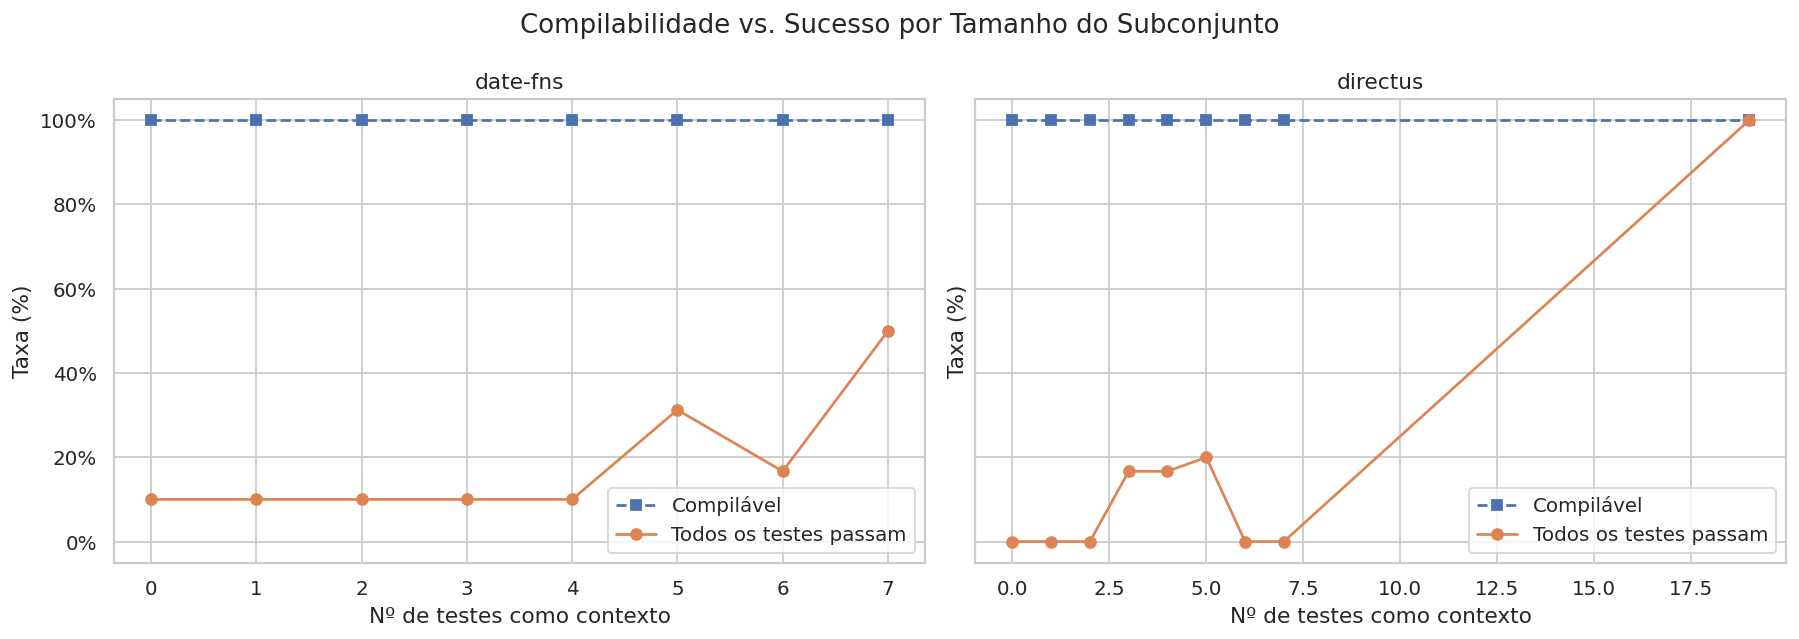

In [183]:
compilable_vs_pass = (
    df.groupby(["repositoryName", "subsetSize"])
    .agg(
        compilable=("isModelResultCompilable", "mean"),
        success=("isTestSuiteSuccessful", "mean")
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, repo in zip(axes, ["date-fns", "directus"]):
    d = compilable_vs_pass[compilable_vs_pass["repositoryName"] == repo]
    ax.plot(d["subsetSize"], d["compilable"] * 100, marker="s", label="Compilável", linestyle="--")
    ax.plot(d["subsetSize"], d["success"] * 100, marker="o", label="Todos os testes passam")
    ax.set_title(f"{repo}")
    ax.set_xlabel("Nº de testes como contexto")
    ax.set_ylabel("Taxa (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend()

plt.suptitle("Compilabilidade vs. Sucesso por Tamanho do Subconjunto")
plt.tight_layout()
plt.savefig("compilable_vs_success.png", bbox_inches="tight")
plt.show()

## Exploração com PandasAI

Faça perguntas em linguagem natural sobre os dados. O agente pode retornar texto ou gerar gráficos automaticamente.

In [189]:
import os
from dotenv import load_dotenv
from google import genai
from pandasai import Agent
from pandasai.llm.base import LLM

load_dotenv("../.env")

class GoogleGenAILLM(LLM):
    def __init__(self, model: str, api_key: str):
        self.model = model
        self._client = genai.Client(api_key=api_key)

    def call(self, instruction, context=None):
        self.last_prompt = instruction.to_string()
        response = self._client.models.generate_content(
            model=self.model,
            contents=self.last_prompt,
        )
        return response.text

    @property
    def type(self) -> str:
        return "google-genai"

df_slim = df.apply(lambda col: col.map(lambda v: str(v)[:500] if isinstance(v, str) else v))

llm = GoogleGenAILLM(model="gemini-3-flash-preview", api_key=os.environ["GOOGLE_GENERATIVE_AI_API_KEY"])
agent = Agent([df_slim], config={"llm": llm, "verbose": False, "custom_whitelisted_dependencies": ["os"], "open_charts": False})

In [190]:
from IPython.display import display, Markdown, Image
import os

def show_agent_result(result):
    if isinstance(result, str) and os.path.isfile(result):
        display(Image(filename=result))
    elif isinstance(result, str):
        display(Markdown(result))
    else:
        display(result)

result = agent.chat("Qual modelo desempenhou melhor?")
show_agent_result(result)

O modelo que desempenhou melhor foi o 'gemini-3.0-flash' com uma taxa de acerto média (passRate) de 0.76.